In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import linregress
indiceshist = [1, 2, 4, 6, 7] + list(range(9, 13)) + list(range(14, 20)) + list(range(21, 26))
indiceshistAer = [1, 4]
indiceshistVeg = list(range(1, 7)) + [12, 14]
indicesssp126 = [1, 4, 6, 9, 11, 15]
indices_ssp245 = [1, 2, 4, 6, 7, 9, 11, 12 ] + list(range(14, 20)) + list(range(21, 26))
# Define file paths for different scenarios
files_historical = [f'D:/Jubjang/FWICMIP6/fwisa_ann_EC-Earth3_historical_r{i}i1p1f1_g025.nc' for i in indiceshist]
files_historical_AerChem = [f'D:/Jubjang/FWICMIP6/fwisa_ann_EC-Earth3-AerChem_historical_r{i}i1p1f1_g025.nc' for i in indiceshistAer]
files_historical_CC = [f'D:/Jubjang/FWICMIP6/fwisa_ann_EC-Earth3-CC_historical_r{i}i1p1f1_g025.nc' for i in indiceshistAer]
files_historical_Veg = [f'D:/Jubjang/FWICMIP6/fwisa_ann_EC-Earth3-Veg_historical_r{i}i1p1f1_g025.nc' for i in indiceshistVeg]
files_historical_Veg_LR = [f'D:/Jubjang/FWICMIP6/fwisa_ann_EC-Earth3-Veg-LR_historical_r{i}i1p1f1_g025.nc' for i in range(1, 4)]
file_SSP119 = 'D:/Jubjang/FWICMIP6/fwisa_ann_EC-Earth3_ssp119_r4i1p1f1_g025.nc'
file_SSP245Veg = 'D:/Jubjang/FWICMIP6/fwisa_ann_EC-Earth3-Veg_ssp245_r5i1p1f1_g025.nc'
files_SSP126 = [f'D:/Jubjang/FWICMIP6/fwisa_ann_EC-Earth3_ssp126_r{i}i1p1f1_g025.nc' for i in indicesssp126]
files_SSP245 = [f'D:/Jubjang/FWICMIP6/fwisa_ann_EC-Earth3_ssp245_r{i}i1p1f1_g025.nc' for i in indices_ssp245]
files_SSP370 = [f'D:/Jubjang/FWICMIP6/fwisa_ann_EC-Earth3_ssp370_r{i}i1p1f1_g025.nc' for i in indicesssp126]
files_SSP585 = [f'D:/Jubjang/FWICMIP6/fwisa_ann_EC-Earth3_ssp585_r{i}i1p1f1_g025.nc' for i in indicesssp126]

print(files_historical)

# Function to load datasets from a list of file paths
def load_datasets(file_list):
    return [xr.open_mfdataset(file, combine='by_coords', engine='netcdf4') for file in file_list]

# Load datasets
datasets_historical = load_datasets(files_historical)
datasets_historical_AerChem = load_datasets(files_historical_AerChem)
datasets_historical_CC = load_datasets(files_historical_CC)
datasets_historical_Veg = load_datasets(files_historical_Veg)
datasets_historical_Veg_LR = load_datasets(files_historical_Veg_LR)
dataset_SSP119 = xr.open_mfdataset(file_SSP119, combine='by_coords', engine='netcdf4')
datasets_SSP126 = load_datasets(files_SSP126)
datasets_SSP245 = load_datasets(files_SSP245)
datasets_SSP245Veg = xr.open_mfdataset(file_SSP245Veg, combine='by_coords', engine='netcdf4')
datasets_SSP370 = load_datasets(files_SSP370)
datasets_SSP585 = load_datasets(files_SSP585)

print("Datasets successfully loaded!")
datasets_historical[0].coords['lat']

['D:/Jubjang/FWICMIP6/fwisa_ann_EC-Earth3_historical_r1i1p1f1_g025.nc', 'D:/Jubjang/FWICMIP6/fwisa_ann_EC-Earth3_historical_r2i1p1f1_g025.nc', 'D:/Jubjang/FWICMIP6/fwisa_ann_EC-Earth3_historical_r4i1p1f1_g025.nc', 'D:/Jubjang/FWICMIP6/fwisa_ann_EC-Earth3_historical_r6i1p1f1_g025.nc', 'D:/Jubjang/FWICMIP6/fwisa_ann_EC-Earth3_historical_r7i1p1f1_g025.nc', 'D:/Jubjang/FWICMIP6/fwisa_ann_EC-Earth3_historical_r9i1p1f1_g025.nc', 'D:/Jubjang/FWICMIP6/fwisa_ann_EC-Earth3_historical_r10i1p1f1_g025.nc', 'D:/Jubjang/FWICMIP6/fwisa_ann_EC-Earth3_historical_r11i1p1f1_g025.nc', 'D:/Jubjang/FWICMIP6/fwisa_ann_EC-Earth3_historical_r12i1p1f1_g025.nc', 'D:/Jubjang/FWICMIP6/fwisa_ann_EC-Earth3_historical_r14i1p1f1_g025.nc', 'D:/Jubjang/FWICMIP6/fwisa_ann_EC-Earth3_historical_r15i1p1f1_g025.nc', 'D:/Jubjang/FWICMIP6/fwisa_ann_EC-Earth3_historical_r16i1p1f1_g025.nc', 'D:/Jubjang/FWICMIP6/fwisa_ann_EC-Earth3_historical_r17i1p1f1_g025.nc', 'D:/Jubjang/FWICMIP6/fwisa_ann_EC-Earth3_historical_r18i1p1f1_g025.nc

<xarray.DataArray 'lat' (lat: 72)>
array([-88.75, -86.25, -83.75, -81.25, -78.75, -76.25, -73.75, -71.25, -68.75,
       -66.25, -63.75, -61.25, -58.75, -56.25, -53.75, -51.25, -48.75, -46.25,
       -43.75, -41.25, -38.75, -36.25, -33.75, -31.25, -28.75, -26.25, -23.75,
       -21.25, -18.75, -16.25, -13.75, -11.25,  -8.75,  -6.25,  -3.75,  -1.25,
         1.25,   3.75,   6.25,   8.75,  11.25,  13.75,  16.25,  18.75,  21.25,
        23.75,  26.25,  28.75,  31.25,  33.75,  36.25,  38.75,  41.25,  43.75,
        46.25,  48.75,  51.25,  53.75,  56.25,  58.75,  61.25,  63.75,  66.25,
        68.75,  71.25,  73.75,  76.25,  78.75,  81.25,  83.75,  86.25,  88.75])
Coordinates:
  * lat      (lat) float64 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y

In [2]:
# Define Earth's radius in meters
R = 6378137

# Latitude and longitude arrays (in degrees)
lon = datasets_historical[0].coords['lon']
lat = datasets_historical[0].coords['lat']

# Convert to radians
lon_radians = np.radians(lon)
lat_radians = np.radians(lat)

# Calculate the differences in longitude and latitude
delta_lon = np.diff(lon_radians)[0]  # Assuming regular grid
delta_lat = np.diff(lat_radians).mean()  # Take the mean for approximate spacing

# Calculate area for each grid cell
area = np.zeros((len(lat), len(lon)))  # Initialize area array to match full grid

for i in range(len(lat)):
    # Latitude bounds (extend to midpoints for full grid)
    if i == 0:  # Southernmost edge
        phi1 = lat_radians[i] - delta_lat / 2
        phi2 = lat_radians[i] + delta_lat / 2
    elif i == len(lat) - 1:  # Northernmost edge
        phi1 = lat_radians[i] - delta_lat / 2
        phi2 = lat_radians[i] + delta_lat / 2
    else:  # Interior latitudes
        phi1 = lat_radians[i] - delta_lat / 2
        phi2 = lat_radians[i] + delta_lat / 2

    # Calculate area for this latitude band
    area[i, :] = (R**2 * delta_lon * (np.sin(phi2) - np.sin(phi1)))

# Convert to square kilometers
area_km2 = area / 1e6

# Print or save the area array
print("Area array (in km^2):", area_km2)
print("Shape of area array:", area_km2.shape)


Area array (in km^2): [[1689.43277819 1689.43277819 1689.43277819 ... 1689.43277819
  1689.43277819 1689.43277819]
 [5065.08240325 5065.08240325 5065.08240325 ... 5065.08240325
  5065.08240325 5065.08240325]
 [8431.09035608 8431.09035608 8431.09035608 ... 8431.09035608
  8431.09035608 8431.09035608]
 ...
 [8431.09035608 8431.09035608 8431.09035608 ... 8431.09035608
  8431.09035608 8431.09035608]
 [5065.08240325 5065.08240325 5065.08240325 ... 5065.08240325
  5065.08240325 5065.08240325]
 [1689.43277819 1689.43277819 1689.43277819 ... 1689.43277819
  1689.43277819 1689.43277819]]
Shape of area array: (72, 144)


In [3]:
# Define latitude and longitude values
# Define latitude and longitude values (adjust based on your actual dataset)
num_lat = 72  # Number of latitude points
num_lon = 144  # Number of longitude points
lat = np.linspace(-88.75, 88.75, num_lat)  # Correct number of points
lon = np.linspace(1.25, 358.75, num_lon)  # Correct number of points

# Create the DataArray
areacella = xr.DataArray(
    area_km2,
    dims=["lat", "lon"],
    coords={"lat": lat, "lon": lon},
    name="area"  # Provide a meaningful name for the data variable
)

# Convert the DataArray into a Dataset
areacella = xr.Dataset({"area": areacella})

# Inspect the Dataset
print(areacella)


<xarray.Dataset>
Dimensions:  (lat: 72, lon: 144)
Coordinates:
  * lat      (lat) float64 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
  * lon      (lon) float64 1.25 3.75 6.25 8.75 11.25 ... 351.2 353.8 356.2 358.8
Data variables:
    area     (lat, lon) float64 1.689e+03 1.689e+03 ... 1.689e+03 1.689e+03


In [4]:
# Latitude and longitude range for Thailand (adjust as needed based on data)
thailand_lat_range = slice(5.5, 20.5)  # Latitude range for Thailand (from 20.5°N to 5.5°N)
thailand_lon_range = slice(97.5, 105.5)  # Longitude range for Thailand (from 97.5°E to 105.5°E)
    
areacella_th=areacella.sel(lat=thailand_lat_range, lon=thailand_lon_range)

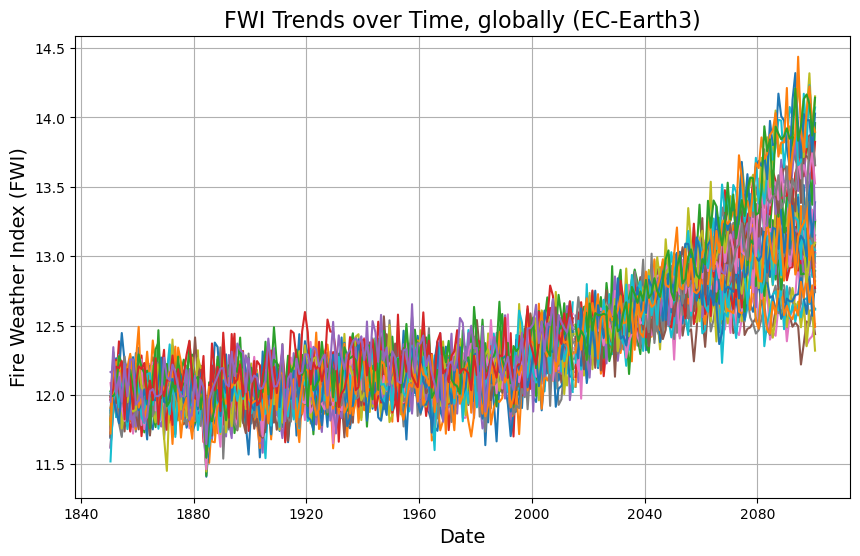

In [22]:
def plot_fwi_trends(datasets, labels, title):
    """ 
    Plot FWI trends over time for given datasets. 
    
    Args:
        datasets (list): List of xarray datasets.
        labels (list): Corresponding labels for each dataset.
        title (str): Title for the plot.
    """
    plt.figure(figsize=(10, 6))
    
    # Plot each dataset
    for dataset, label in zip(datasets, labels):
        plt.plot(
            dataset['time'], 
            dataset['fwisa'].mean(dim=['lat', 'lon']), 
            label=label
        )
    
    # Plot customization
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Fire Weather Index (FWI)', fontsize=14)
    plt.title(title, fontsize=16)
#     plt.legend(fontsize=3.5)
    plt.grid(True)
    plt.savefig("FWI Trends over Time, globally (EC-Earth3).png")
    plt.show()

# Group datasets and labels
datasets_all_scenarios = (
    datasets_historical + 
    datasets_historical_AerChem  +
    datasets_historical_CC +
    datasets_historical_Veg +
    datasets_historical_Veg_LR +
    [dataset_SSP119] + datasets_SSP126 + datasets_SSP245 +
    [datasets_SSP245Veg] +
    datasets_SSP370  + datasets_SSP585
)

labels_all_scenarios = (
    [f'Historical r{i}i1p1f1' for i in indiceshist] +
    [f'AerChem_Historical r{i}i1p1f1' for i in indiceshistAer] +
    [f'CC_Historical r{i}i1p1f1' for i in indiceshistAer] +
    [f'Veg_Historical r{i}i1p1f1' for i in indiceshistVeg] +
    [f'Veg-LR_Historical r{i}i1p1f1' for i in range(1, 4)] +
    ['SSP119 r4i1p1f1'] +
    [f'SSP126 r{i}i1p1f1' for i in indicesssp126] +
    [f'SSP245 r{i}i1p1f1' for i in indices_ssp245] +
    [f'SSP370 r{i}i1p1f1' for i in indicesssp126] +
    [f'SSP585 r{i}i1p1f1' for i in indicesssp126]
)

# Plot FWI trends for all scenarios
plot_fwi_trends(datasets_all_scenarios, labels_all_scenarios , 'FWI Trends over Time, globally (EC-Earth3)')

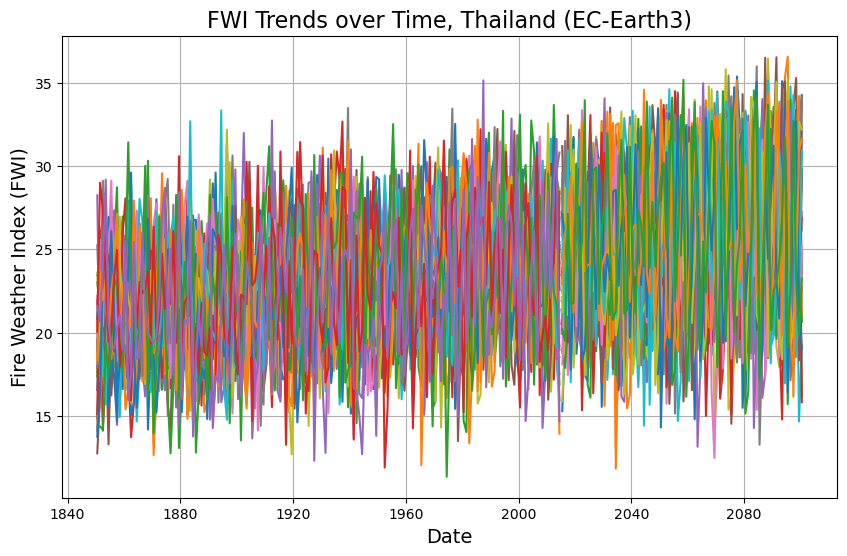

In [21]:
def plot_fwi_trends_th(datasets, labels, title):
    """ 
    Plot FWI trends over time for given datasets. 
    
    Args:
        datasets (list): List of xarray datasets.
        labels (list): Corresponding labels for each dataset.
        title (str): Title for the plot.
    """
    plt.figure(figsize=(10, 6))
    
    # Plot each dataset
    for dataset, label in zip(datasets, labels):
        plt.plot(
            dataset['time'], 
            (dataset['fwisa'].sel(lat=thailand_lat_range, lon=thailand_lon_range)).weighted(areacella['area']).mean(dim=['lat', 'lon']), 
            label=label
        )
    
    # Plot customization
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Fire Weather Index (FWI)', fontsize=14)
    plt.title(title, fontsize=16)
#     plt.legend(fontsize=3.5)
    plt.grid(True)
    plt.savefig("FWI Trends over Time, Thailand (EC-Earth3)")
    plt.show()


# Plot FWI trends for all scenarios
plot_fwi_trends_th(datasets_all_scenarios, labels_all_scenarios, 'FWI Trends over Time, Thailand (EC-Earth3)')

In [7]:
datasets_all_scenarios = (
    datasets_historical + 
    datasets_historical_AerChem  +
    datasets_historical_CC +
    datasets_historical_Veg +
    datasets_historical_Veg_LR +
    [dataset_SSP119] + datasets_SSP126 + datasets_SSP245 +
    [datasets_SSP245Veg] +
    datasets_SSP370  + datasets_SSP585
)

In [14]:
def load_and_concatenate(file_list):
    datasets = [xr.open_dataset(file, engine='netcdf4') for file in file_list]
    concatenated = xr.concat(datasets, dim='ensemble')
    return concatenated

# Define a function to process and compute ensemble statistics
def process_ssp_data(file_list, lat_range, lon_range, area_weights):
    # Load and concatenate datasets
    ssp_data = load_and_concatenate(file_list)
    
    # Select the Thailand region based on latitude and longitude ranges
    ssp_data_th = ssp_data.sel(lat=lat_range, lon=lon_range)
    
    # Compute ensemble mean and standard deviation weighted by area
    ensemble_mean = (ssp_data_th.weighted(area_weights['area']).mean(dim=['lat', 'lon'])).mean(dim='ensemble')
    ensemble_std = (ssp_data_th.weighted(area_weights['area']).mean(dim=['lat', 'lon'])).std(dim='ensemble')
    
    return ensemble_mean, ensemble_std

# Process data for all SSP scenarios
historical_mean_th, historical_std_th = process_ssp_data(files_historical, thailand_lat_range, thailand_lon_range, areacella_th)
historical_AerChem_mean_th, historical_AerChem_std_th = process_ssp_data(files_historical_AerChem, thailand_lat_range, thailand_lon_range, areacella_th)
historical_CC_mean_th, historical_CC_std_th = process_ssp_data(files_historical_CC, thailand_lat_range, thailand_lon_range, areacella_th)
historical_Veg_mean_th, historical_Veg_std_th = process_ssp_data(files_historical_Veg, thailand_lat_range, thailand_lon_range, areacella_th)
historical_Veg_LR_mean_th, historical_Veg__LR_std_th = process_ssp_data(files_historical_Veg_LR, thailand_lat_range, thailand_lon_range, areacella_th)
ssp119_mean_th, ssp119_std_th = process_ssp_data([file_SSP119], thailand_lat_range, thailand_lon_range, areacella_th)
ssp126_mean_th, ssp126_std_th = process_ssp_data(files_SSP126, thailand_lat_range, thailand_lon_range, areacella_th)
ssp245_mean_th, ssp245_std_th = process_ssp_data(files_SSP245, thailand_lat_range, thailand_lon_range, areacella_th)
ssp245Veg_mean_th, ssp245Veg_std_th = process_ssp_data([file_SSP245Veg], thailand_lat_range, thailand_lon_range, areacella_th)
ssp370_mean_th, ssp370_std_th = process_ssp_data(files_SSP370, thailand_lat_range, thailand_lon_range, areacella_th)
ssp585_mean_th, ssp585_std_th = process_ssp_data(files_SSP585, thailand_lat_range, thailand_lon_range, areacella_th)


In [15]:
datasets_thailand = [
    ds.sel(lat=thailand_lat_range, lon=thailand_lon_range) for ds in datasets_all_scenarios
]

In [16]:
def plot_fwi_trends_withlines(datasets, ensemble_means, ensemble_stds, title):
    """ 
    Plot FWI trends over time for given datasets with ensemble mean and boundaries.
    
    Args:
        datasets (list): List of xarray datasets (individual simulations).
        ensemble_means (list): List of xarray DataArrays for ensemble means.
        ensemble_stds (list): List of xarray DataArrays for ensemble standard deviations.
        title (str): Title for the plot.
    """
    plt.figure(figsize=(14, 8))  # Increase plot size

    # Plot individual datasets in a lighter color
    for dataset in datasets[:200]:  # Limit to first 10 datasets for clarity
        # Ensure the 'time' coordinate exists in the dataset
        time = dataset.coords.get('time', None)
        if time is not None and 'fwisa' in dataset:
            # Spatially average to reduce to 1D (time dimension only)
            spatial_mean = dataset['fwisa'].weighted(areacella['area']).mean(dim=['lat', 'lon'], skipna=True)
            #spatial_mean = dataset['fwisa'].mean(dim=['lat', 'lon'], skipna=True)
            plt.plot(
                time, 
                spatial_mean, 
                color='lightblue', alpha=0.2  # Increase transparency
            )

    # Define distinct colors for each ensemble mean
    colors = [
        'darkblue',    # Historical
        'navy',        # Historical AerChem
        'steelblue',   # Historical CC
        'green',       # Historical Veg
        'forestgreen', # Historical Veg-LR
        'red',         # SSP119
        'purple',      # SSP126
        'orange',      # SSP245
        'gold',        # SSP245 Veg
        'brown',       # SSP370
        'black'        # SSP585
    ]

    # Define custom boundary colors for better visualization
    boundary_colors = [
        'skyblue',     # Historical
        'deepskyblue', # Historical AerChem
        'powderblue',  # Historical CC
        'lightgreen',  # Historical Veg
        'darkseagreen',# Historical Veg-LR
        'salmon',      # SSP119
        'plum',        # SSP126
        'goldenrod',   # SSP245
        'khaki',       # SSP245 Veg
        'tan',         # SSP370
        'dimgray'      # SSP585
    ]

    # Define scenario labels for the legend
    scenario_labels = [
        'Historical', 
        'Historical AerChem', 
        'Historical CC', 
        'Historical Veg', 
        'Historical Veg-LR', 
        'SSP119', 
        'SSP126', 
        'SSP245', 
        'SSP245 Veg', 
        'SSP370', 
        'SSP585'
    ]

    
    # Plot each ensemble mean in a distinct color with a dynamic label
    for ensemble_mean, ensemble_std, label, color, boundary_color in zip(ensemble_means, ensemble_stds, scenario_labels, colors, boundary_colors):
        # Extract DataArrays (assuming fwisa is the variable of interest)
        if isinstance(ensemble_mean, xr.Dataset):
            ensemble_mean = ensemble_mean['fwisa']
        if isinstance(ensemble_std, xr.Dataset):
            ensemble_std = ensemble_std['fwisa']

        time = ensemble_mean.coords.get('time', None)
        if time is not None:
            # Ensemble mean should already be spatially averaged
            plt.plot(
                time, 
                ensemble_mean, 
                color=color, linewidth=2.5, label=f'Ensemble Mean ({label})'
            )
            
            # Skip uncertainty for SSP119
            if label == 'SSP119':
                continue
            
            if "Veg" in label:
                continue
            
            # Calculate the uncertainty bounds (lower and upper)
            lower_bound = ensemble_mean - ensemble_std
            upper_bound = ensemble_mean + ensemble_std
            
            # Plot the shaded region representing uncertainty
            plt.fill_between(
                time, 
                lower_bound, 
                upper_bound, 
                color=boundary_color, alpha=0.40, label=f'Uncertainty ({label})'
            )
    
    # Plot customization
    plt.xlabel('Date', fontsize=16)
    plt.ylabel('Fire Weather Index (FWI)', fontsize=16)
    plt.title(title, fontsize=18)
    plt.legend(fontsize=12, loc='upper left')  # Increase legend font size
    plt.grid(True, linestyle='--', alpha=0.6)  # Add grid with more transparency
    plt.tight_layout()
    plt.savefig("FWI Trends over Time, Thailand (EC-Earth3) with lines")
    plt.show()


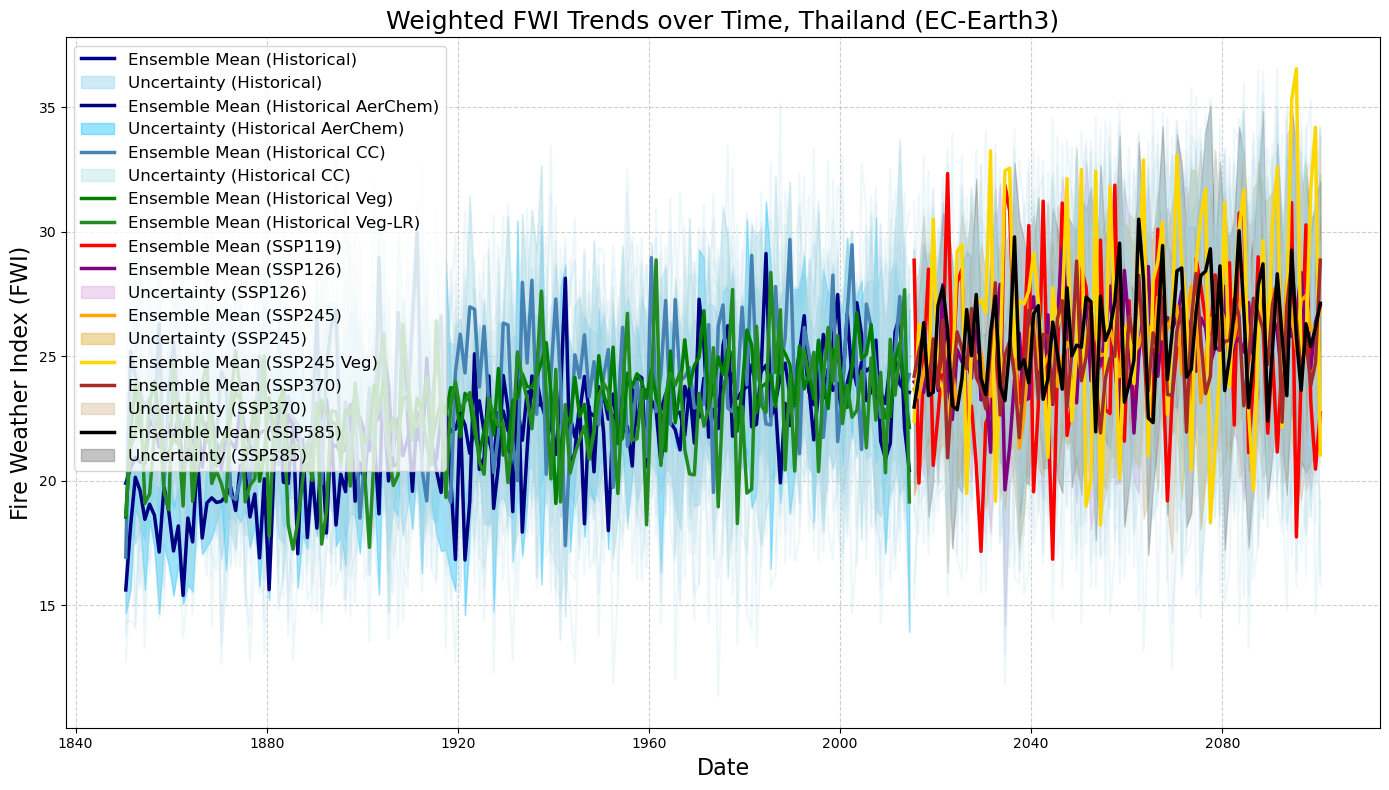

In [17]:
# Example input (replace with your actual data)
ensemble_means_all_scenarios_th = [
    historical_mean_th, historical_AerChem_mean_th, historical_CC_mean_th, historical_Veg_mean_th,
    historical_Veg_LR_mean_th, ssp119_mean_th, ssp126_mean_th, ssp245_mean_th,
    ssp245Veg_mean_th, ssp370_mean_th, ssp585_mean_th
]
ensemble_stds_all_scenarios_th = [
    historical_std_th, historical_AerChem_std_th, historical_CC_std_th, historical_Veg_std_th,
    historical_Veg__LR_std_th, ssp119_std_th, ssp126_std_th, ssp245_std_th,
    ssp245Veg_std_th, ssp370_std_th, ssp585_std_th
]

# Plot the FWI trends over time for all scenarios with ensemble means and boundaries
plot_fwi_trends_withlines(
    datasets_thailand, 
    ensemble_means_all_scenarios_th, 
    ensemble_stds_all_scenarios_th, 
    'Weighted FWI Trends over Time, Thailand (EC-Earth3)'
)

In [12]:
# Define a function to process and compute ensemble statistics
def process_ssp_data(file_list, area_weights):
    # Load and concatenate datasets
    ssp_data = load_and_concatenate(file_list)
    
    # Compute ensemble mean and standard deviation weighted by area
    ensemble_mean = (ssp_data.weighted(area_weights['area']).mean(dim=['lat', 'lon'])).mean(dim='ensemble')
    ensemble_std = (ssp_data.weighted(area_weights['area']).mean(dim=['lat', 'lon'])).std(dim='ensemble')
    
    return ensemble_mean, ensemble_std

# Process data for all SSP scenarios
historical_mean, historical_std = process_ssp_data(files_historical, areacella)
historical_AerChem_mean, historical_AerChem_std = process_ssp_data(files_historical_AerChem, areacella)
historical_CC_mean, historical_CC_std = process_ssp_data(files_historical_CC, areacella)
historical_Veg_mean, historical_Veg_std = process_ssp_data(files_historical_Veg, areacella)
historical_Veg_LR_mean, historical_Veg__LR_std = process_ssp_data(files_historical_Veg_LR, areacella)
ssp119_mean, ssp119_std = process_ssp_data([file_SSP119], areacella)
ssp126_mean, ssp126_std = process_ssp_data(files_SSP126, areacella)
ssp245_mean, ssp245_std = process_ssp_data(files_SSP245, areacella)
ssp245Veg_mean, ssp245Veg_std = process_ssp_data([file_SSP245Veg], areacella)
ssp370_mean, ssp370_std = process_ssp_data(files_SSP370, areacella)
ssp585_mean, ssp585_std = process_ssp_data(files_SSP585, areacella)


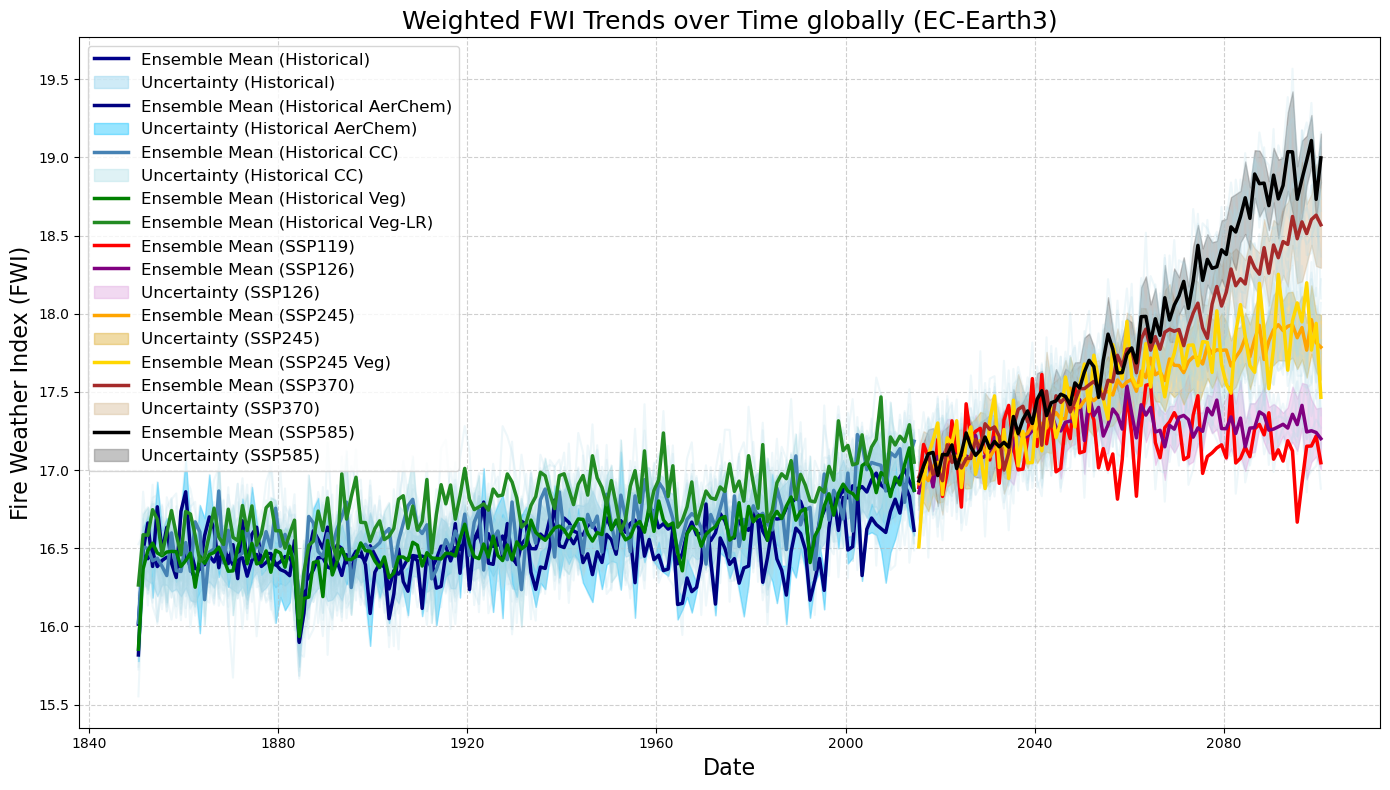

In [13]:
ensemble_means_all_scenarios = [
    historical_mean, historical_AerChem_mean, historical_CC_mean, historical_Veg_mean,
    historical_Veg_LR_mean, ssp119_mean, ssp126_mean, ssp245_mean,
    ssp245Veg_mean, ssp370_mean, ssp585_mean
]
ensemble_stds_all_scenarios = [
    historical_std, historical_AerChem_std, historical_CC_std, historical_Veg_std,
    historical_Veg__LR_std, ssp119_std, ssp126_std, ssp245_std,
    ssp245Veg_std, ssp370_std, ssp585_std
]


plot_fwi_trends_withlines(
    datasets_all_scenarios, 
    ensemble_means_all_scenarios, 
    ensemble_stds_all_scenarios, 
    'Weighted FWI Trends over Time globally (EC-Earth3)'
)